- Convolutional layer
- Pooling layer
- Fully connected layer
- Measurement
- Training alg

In [2]:
from qiskit import QuantumCircuit
import numpy as np



# Convolutional layer

- U3 gates
- Ising-family gates (XX, YY, ZZ)

U = U3(p1,q1,r1) X U3 (p2,q2,r2) · I singZZ(gamma) · I singYY(betha) · I singXX(alpha)

9 trainable params

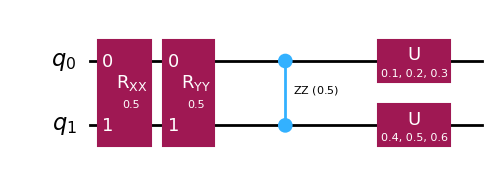

In [4]:
def conv_circuit(params):
    qc = QuantumCircuit(2)
    qc.rxx(params[0], 0, 1)
    qc.ryy(params[1], 0, 1)
    qc.rzz(params[2], 0, 1)
    qc.u(params[3], params[4], params[5], 0)
    qc.u(params[6], params[7], params[8], 1)
    return qc

qc = conv_circuit([0.5, 0.5, 0.5, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
qc.draw('mpl', filename='conv_circuit.png')


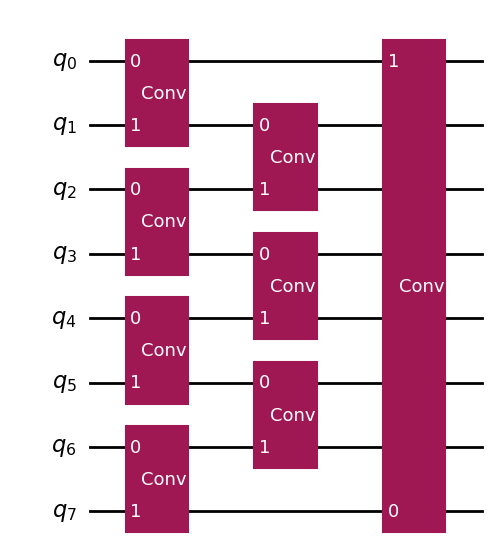

In [5]:
def conv_layer(n_qubits, params):
    qc = QuantumCircuit(n_qubits)
    gate = conv_circuit(params).to_gate(label='Conv')
    
    for i in range(0, n_qubits, 2):
        qc.append(gate, [i, i+1])
    
    for i in range(1, n_qubits, 2):
        qc.append(gate, [i, (i+1) % n_qubits])
    
    return qc

params = [0.5]*9

qc = conv_layer(8, params)
qc.draw('mpl')

# Pooling layer

V = U3(p,q,r)

2 qubits, 1 controls whether a transformation is applied to the second qubit.

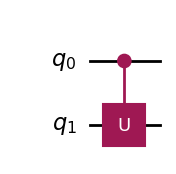

In [6]:
def pooling_circuit(params):
    qc = QuantumCircuit(2)
    
    u_gate = QuantumCircuit(1)
    u_gate.u(params[0], params[1], params[2], 0)
    
    controlled = u_gate.to_gate(label='U').control(1)
    qc.append(controlled, [0, 1])
    
    return qc

qc = pooling_circuit([0.1, 0.2, 0.3])
qc.draw('mpl', filename='pooling_circuit.png')

In [7]:
def pooling_layer(n_qubits,params):
    qc = QuantumCircuit(n_qubits)
    gate = pooling_circuit(params).to_gate(label='Pool')
    
    kept_qubits = []

    for i in range(0, n_qubits, 2):
        qc.append(gate, [i, i+1])
        kept_qubits.append(i+1)
    
    return qc,kept_qubits

params = [0.1, 0.2, 0.3]
qc, kept_qubits = pooling_layer(8, params)
qc.draw('mpl')
print("Kept qubits after pooling:", kept_qubits)


Kept qubits after pooling: [1, 3, 5, 7]


# Fully connected layer



In [ ]:
#????

#QANN circuit

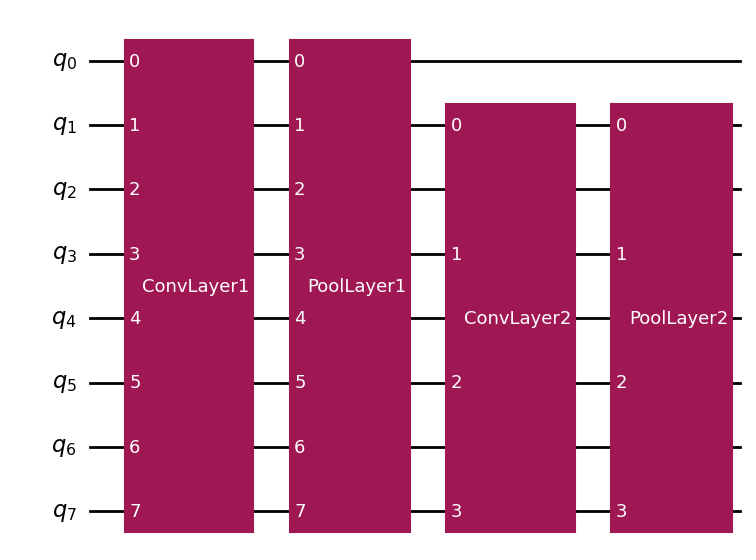

In [13]:
def QANN_circuit(n_qubits, conv_params, pool_params):
    qc = QuantumCircuit(n_qubits)
    
    conv1_gate = conv_layer(n_qubits, conv_params).to_gate(label='ConvLayer1')
    qc.append(conv1_gate, range(n_qubits))
    
    pool1_gate, kept_qubits = pooling_layer(n_qubits, pool_params)
    qc.append(pool1_gate.to_gate(label='PoolLayer1'), range(n_qubits))

    m_qubits = len(kept_qubits)
    conv2_gate = conv_layer(m_qubits, conv_params).to_gate(label='ConvLayer2')
    qc.append(conv2_gate, kept_qubits)

    pool2_gate, kept_qubits2 = pooling_layer(m_qubits, pool_params)
    qc.append(pool2_gate.to_gate(label='PoolLayer2'), kept_qubits)
    
    return qc, kept_qubits2

qc, kept_qubits = QANN_circuit(8, [0.5]*9, [0.1, 0.2, 0.3])
qc.draw('mpl')
#print("Final kept qubits after QANN:", kept_qubits)